# Análisis exploratorio de datos (EDA)

Exploración del dataset UCI Chronic Kidney Disease (400 instancias, 25 atributos).
La lógica pesada vive en `src/`; aquí solo exploramos y visualizamos.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # raiz del proyecto para importar src
import logging
logging.basicConfig(level=logging.INFO)

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src import data_loader as dl, config
df = dl.load_ckd_dataset()
df.shape

INFO:src.data_loader:Dataset crudo cargado: 400 filas x 25 columnas


(400, 25)

## Distribución de clases

In [3]:
df['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

## Valores faltantes por variable

In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0]

rbc      0.3800
rc       0.3275
wc       0.2650
pot      0.2200
sod      0.2175
pcv      0.1775
pc       0.1625
hemo     0.1300
su       0.1225
sg       0.1175
al       0.1150
bgr      0.1100
bu       0.0475
sc       0.0425
bp       0.0300
age      0.0225
ba       0.0100
pcc      0.0100
dm       0.0075
htn      0.0050
cad      0.0050
appet    0.0025
pe       0.0025
ane      0.0025
dtype: float64

In [5]:
print(f"Filas con al menos un NaN: {df.isna().any(axis=1).mean():.1%}")

Filas con al menos un NaN: 60.8%


## Hallazgo clave: el subgrupo diabético no es modelable

El paper planteaba el análisis primario sobre pacientes diabéticos (`dm == 'yes'`).
Sin embargo, en este dataset **todos los diabéticos tienen ERC**, por lo que el
subgrupo tiene una sola clase y no permite entrenar un clasificador. Por eso el
modelado se hace sobre el dataset completo y el ángulo diabético queda como
observación de prevalencia.

In [6]:
dm_yes = dl.filter_diabetic_subset(df)
print('Pacientes diabéticos:', len(dm_yes))
dm_yes['classification'].value_counts()

INFO:src.data_loader:Subgrupo diabetico: 137 filas


Pacientes diabéticos: 137


classification
ckd    137
Name: count, dtype: int64

## Distribuciones de variables numéricas

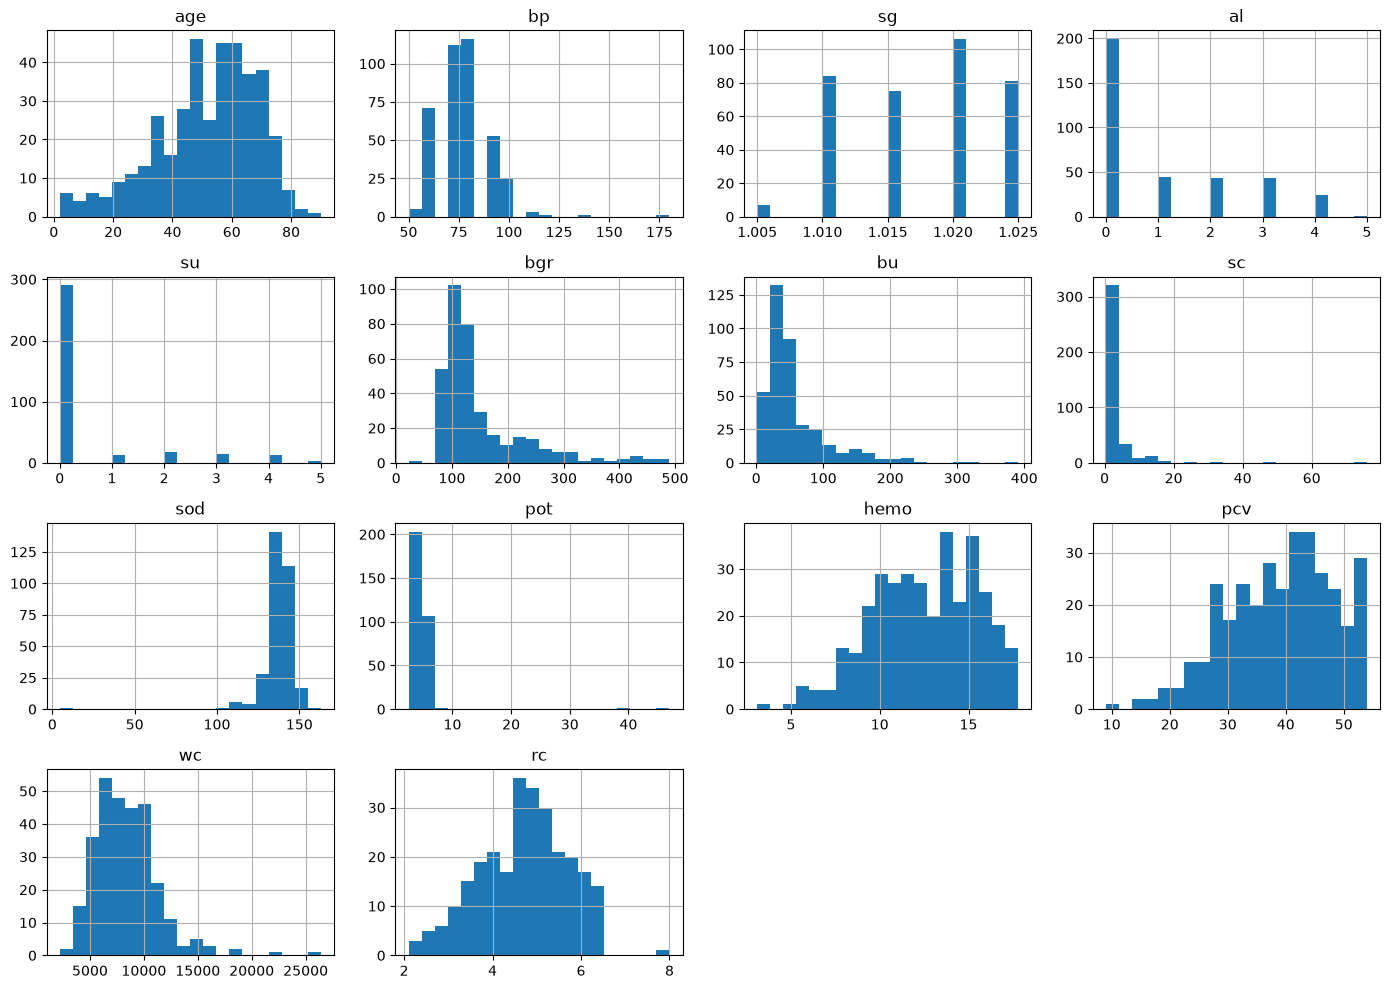

In [7]:
num = config.NUMERIC_COLS
df[num].hist(figsize=(14, 10), bins=20)
plt.tight_layout(); plt.show()

## Creatinina y hemoglobina por clase (boxplots)

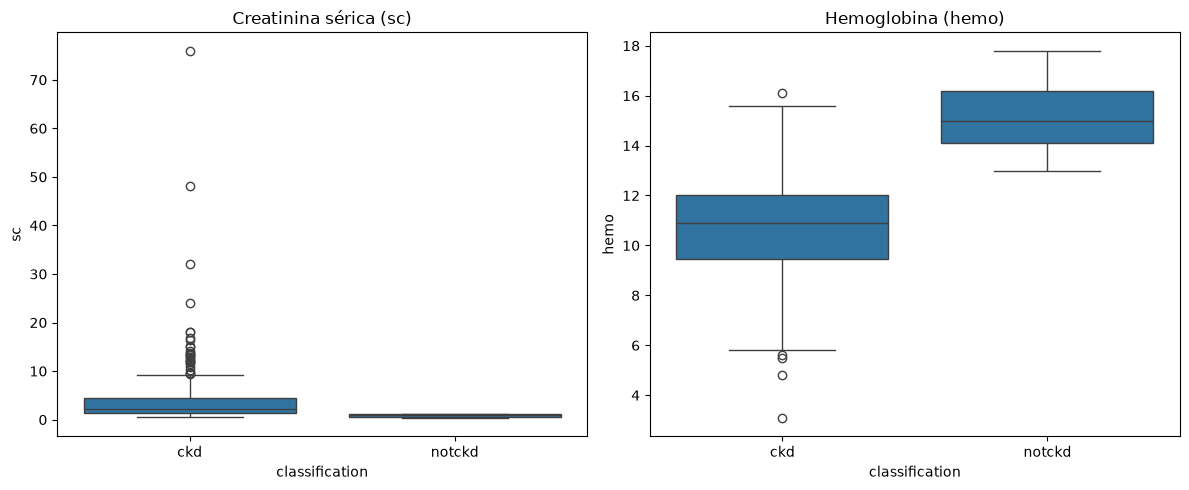

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='classification', y='sc', ax=axes[0]); axes[0].set_title('Creatinina sérica (sc)')
sns.boxplot(data=df, x='classification', y='hemo', ax=axes[1]); axes[1].set_title('Hemoglobina (hemo)')
plt.tight_layout(); plt.show()

## Matriz de correlación (variables numéricas)

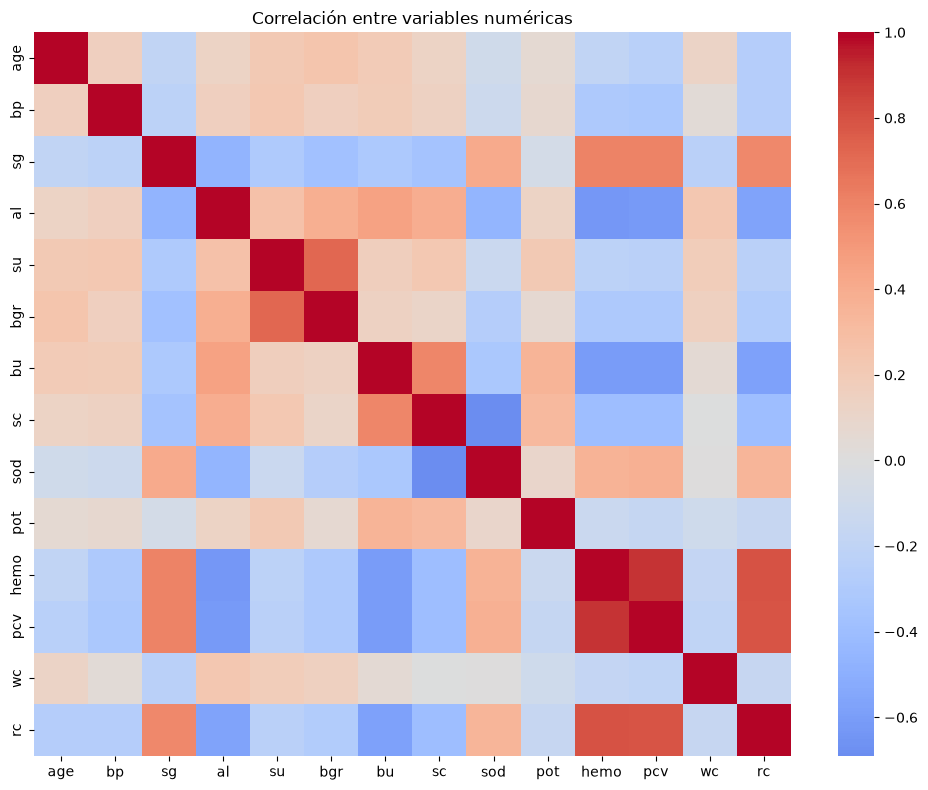

In [9]:
corr = df[num].corr()
plt.figure(figsize=(10, 8)); sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas'); plt.tight_layout(); plt.show()